# Check Point 1 - Machine Learning Operations
# Fondasi Sistem Prediksi *Risk Score* (Chicago Crimes -> Proxy Koordinat Jabodetabek)

1. **Spatial smoothing diperkuat.** Rata-rata tetangga per sel sebelumnya cuma ~8.1 (kurang
   berdampak untuk smoothing) karena `SIGMA_METERS=500` terlalu kecil relatif ukuran grid.
   Dinaikkan ke `SIGMA_METERS=1500` supaya radius pencarian (3xsigma) mencakup lebih banyak sel
   tetangga, jadi pengaruh spasialnya benar-benar kelihatan — lihat Bab 5.3.
2. **`base_value` dan `risk_raw` tidak lagi diekspor ke `features_labels.csv`.** Sebelumnya dua
   kolom ini ikut disimpan di file final, padahal keduanya adalah bahan pembentuk `risk_score`
   itu sendiri — kalau ikut dipakai sebagai fitur di HO2, model bisa "reverse-engineer" jawaban
   dari situ alih-alih belajar pola ruang-waktu. Sekarang keduanya cuma dipakai untuk diagnostik
   internal di notebook ini (Bab 5.4), tidak ikut ke file yang diekspor — lihat Bab 6.
3. **Koordinat dipetakan dari Chicago ke bounding box Jabodetabek.** Karena path lain
   di Final Project (PM, BAS, UI/UX, FE) mendesain aplikasi untuk konteks Jabodetabek,
   `Latitude`/`Longitude` asli Chicago dinormalisasi (min-max, per-axis) ke bounding box
   representatif Jabodetabek segera setelah data cleaning (Bab 2), sebelum EDA & feature
   engineering. Koordinat asli tetap disimpan (`Latitude_Chicago_orig`,
   `Longitude_Chicago_orig`) untuk ketertelusuran — lihat Bab 2.5.

# 0. Setup & Import Library

Stack standar data science: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`.
`scikit-learn` dipakai untuk `BallTree` (mencari tetangga spasial secara efisien, dasar
untuk *spatial decay* di Bagian 5.3).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
RNG = np.random.default_rng(42)
print("Setup selesai OK")


Setup selesai OK


# 1. Load Dataset — Chicago Crimes (2001–Present)

## Subset yang dipakai: berdasarkan WAKTU, bukan wilayah

Deliverable notebook ini adalah **peta risiko/hotspot untuk seluruh kota** (bukan studi satu wilayah saja) — artinya variasi **spasial** (District/Beat/Community Area yang berbeda-beda) justru menjadi hal yang ingin dibandingkan & pelajari. Kalau subset berdasarkan District, kita malah membuang variasi itu.

| Strategi subset | Efeknya | Cocok untuk tugas ini? |
|---|---|---|
| **Waktu** (mis. 2–3 tahun terakhir) | Tetap ada semua District/Beat/Community Area → variasi spasial kota tetap utuh | ✅ **Dipakai di draft ini** |
| **Wilayah** (mis. 2–3 District saja) | Menghilangkan variasi antar-wilayah yang justru jadi inti hotspot map | ⚠️ Hanya cocok kalau tugasnya memang studi kasus 1 wilayah spesifik |

Alasan tambahan memilih subset waktu untuk data kejahatan AS:

- **Pola kejahatan tidak stasioner** : dipengaruhi kebijakan kepolisian, kondisi
  sosial-ekonomi, bahkan efek pandemi COVID-19 (banyak studi mencatat lonjakan/pergeseran pola kejahatan AS pada 2020-2022). Data dari 2001 mungkin sudah tidak representatif untuk menilai risiko "saat ini".
- Subset waktu **tidak mengorbankan cakupan kota** : setiap District/Beat tetap terwakili, sehingga perbandingan hotspot antar-wilayah tetap valid.

In [2]:
import gdown

# File ID dari link dataset pada dokumen hands-on
FILE_ID = "12K13Az7ynV3ZVimSARImgggnbDbVqjk_"
OUTPUT  = "chicago_crimes.csv"

gdown.download(id=FILE_ID, output=OUTPUT, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=12K13Az7ynV3ZVimSARImgggnbDbVqjk_
From (redirected): https://drive.google.com/uc?id=12K13Az7ynV3ZVimSARImgggnbDbVqjk_&confirm=t&uuid=2ce5b47c-a519-40bb-a44c-b4d4f1bf7224
To: /content/chicago_crimes.csv
100%|██████████| 2.37G/2.37G [00:41<00:00, 57.2MB/s]


'chicago_crimes.csv'

In [3]:
usecols = [
    "ID", "Date", "Primary Type", "Description", "Location Description",
    "Arrest", "Domestic", "Beat", "District", "Ward", "Community Area",
    "Latitude", "Longitude", "Year",
]
dtypes = {
    "Primary Type": "category",
    "Description": "category",
    "Location Description": "category",
    "Arrest": "boolean",
    "Domestic": "boolean",
    "Beat": "Int32",
    "District": "Int16",
    "Ward": "Int16",
    "Community Area": "Int16",
    "Year": "Int16",
}

df = pd.read_csv(OUTPUT, usecols=lambda c: c in usecols, dtype=dtypes, low_memory=False)
print("Shape mentah:", df.shape)
df.head()


Shape mentah: (8534663, 14)


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year,Latitude,Longitude
0,14165870,04/11/2026 12:00:00 AM,THEFT,$500 AND UNDER,STREET,False,False,934,9,20,61,2026,41.801025,-87.652621
1,14170655,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,RESIDENCE,False,False,1631,16,38,17,2026,NaN,NaN
2,14164088,04/11/2026 12:00:00 AM,BATTERY,SIMPLE,STREET,False,False,1223,12,27,28,2026,41.884097,-87.675228
3,14163678,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,APARTMENT,True,False,2011,20,40,4,2026,41.977655,-87.697553
4,14164937,04/11/2026 12:00:00 AM,THEFT,THEFT FROM MOTOR VEHICLE,GAS STATION,False,False,1923,19,46,6,2026,41.954538,-87.651148


In [4]:
# Strategi subset: WAKTU

N_YEARS = 3   # -> justifikasi dijelaskan pada laporan
last_year = int(df["Year"].max())
df = df[df["Year"] >= last_year - (N_YEARS - 1)].copy()

print(f"Subset {last_year-(N_YEARS-1)}-{last_year}. Shape:", df.shape)
print("Jumlah District unik pada subset:", df['District'].nunique(), "(pastikan tetap banyak / representatif kota)")

# Kolom "category" (Primary Type, Description, Location Description) masih inget semua
# kategori dari dataset penuh walau sudah di-subset per tahun. Kalau ini nggak dibersihkan,
# value_counts()/groupby() di EDA nanti nampilin puluhan kategori yang sebenarnya kosong,
# jadinya bar chart keliatan aneh/nggak sejajar. remove_unused_categories() nangani ini.
cat_cols = df.select_dtypes(include="category").columns
for c in cat_cols:
    df[c] = df[c].cat.remove_unused_categories()

print("Kategori Primary Type setelah dibersihkan:", df["Primary Type"].nunique(),
      "(harusnya jauh < 33 kalau subset sudah mengecilkan datanya)")


Subset 2024-2026. Shape: (553919, 14)
Jumlah District unik pada subset: 23 (pastikan tetap banyak / representatif kota)
Kategori Primary Type setelah dibersihkan: 31 (harusnya jauh < 33 kalau subset sudah mengecilkan datanya)


# 2. Kualitas & Persiapan Data

Sesuai materi Sesi 1, Kualitas data buruk = model buruk, sepanjang apa pun
pipeline-nya. Sebelum EDA, jalankan pemeriksaan sistematis berikut untuk dataset
terstruktur:

- **Struktur & tipe data** — shape, dtype tiap kolom sudah benar?
- **Missing values** — proporsi null per kolom, acak atau sistematis?
- **Duplikat** — baris ganda penuh atau `ID` ganda?
- **Outlier & anomali** — koordinat di luar Chicago, `Year` tidak masuk akal, dll.
- **Rentang & validitas** — koordinat & timestamp dalam batas wajar?
- **Kardinalitas & konsistensi** — kategori `Primary Type`/`Description` seragam?

In [5]:
# Struktur & tipe data
print(df.shape)
print(df.dtypes)


(553919, 14)
ID                         int64
Date                      object
Primary Type            category
Description             category
Location Description    category
Arrest                   boolean
Domestic                 boolean
Beat                       Int32
District                   Int16
Ward                       Int16
Community Area             Int16
Year                       Int16
Latitude                 float64
Longitude                float64
dtype: object


Longitude               0.545748
Latitude                0.545748
Location Description    0.456926
Community Area          0.003069
Ward                    0.000181
ID                      0.000000
Arrest                  0.000000
Description             0.000000
Primary Type            0.000000
Date                    0.000000
District                0.000000
Beat                    0.000000
Domestic                0.000000
Year                    0.000000
dtype: float64


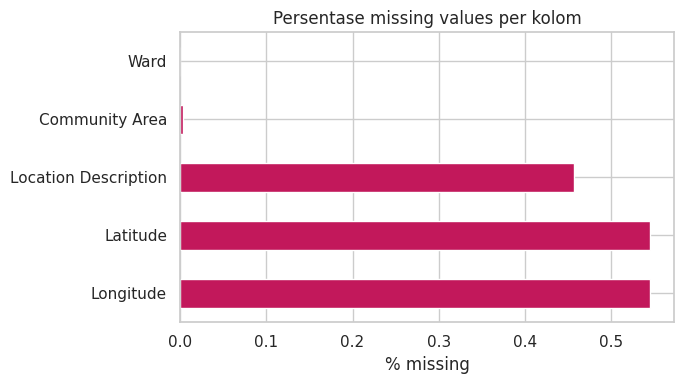

In [6]:
# Missing values per kolom (%)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct)

plt.figure(figsize=(7, 4))
missing_pct[missing_pct > 0].plot(kind="barh", color="#c2185b")
plt.title("Persentase missing values per kolom")
plt.xlabel("% missing")
plt.tight_layout(); plt.show()


In [7]:
# Duplikat
dup_full = df.duplicated().sum()
dup_id   = df.duplicated(subset=["ID"]).sum()
print(f"Baris duplikat penuh : {dup_full}")
print(f"ID duplikat          : {dup_id}")

df = df.drop_duplicates(subset=["ID"]).copy()


Baris duplikat penuh : 0
ID duplikat          : 0


In [8]:
# Parse tanggal & buang baris tanpa koordinat/tanggal valid
df["Datetime"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

before = len(df)
df = df.dropna(subset=["Latitude", "Longitude", "Datetime"]).copy()

# Bounding box kasar Chicago -> menyingkirkan koordinat yang jelas keliru (mis. 0,0 atau typo)
CHI_LAT = (41.60, 42.05)
CHI_LON = (-87.95, -87.50)
df = df[df["Latitude"].between(*CHI_LAT) & df["Longitude"].between(*CHI_LON)].copy()

print(f"Baris sebelum cleaning: {before:,}")
print(f"Baris setelah cleaning: {len(df):,}  ({(len(df)/before*100):.1f}% tersisa)")


Baris sebelum cleaning: 553,919
Baris setelah cleaning: 550,896  (99.5% tersisa)


## 2.5 Transformasi Koordinat: Chicago → Jabodetabek (Proxy)

**Pendekatan:** normalisasi *min-max* linear per-axis, memetakan rentang `Latitude`/
`Longitude` hasil cleaning (Bab 2) ke bounding box representatif Jabodetabek:

| Batas | Nilai | Keterangan |
|---|---|---|
| `lat_new_min` | -6.55 | batas selatan (mencakup Jakarta, Depok, sebagian Bogor) |
| `lat_new_max` | -6.10 | batas utara (pesisir Jakarta Utara) |
| `lon_new_min` | 106.55 | batas barat (sebagian besar wilayah Tangerang) |
| `lon_new_max` | 107.05 | batas timur (Kota Bekasi & sebagian Kab. Bekasi) |

Arah relatif dipertahankan: nilai `Latitude`/`Longitude` **minimum** di Chicago dipetakan
ke **minimum** di Jabodetabek, begitu pula maksimumnya — jadi titik paling utara di
Chicago tetap jadi titik paling utara pada peta baru, titik paling timur tetap paling
timur, dst. Pola spasial (hotspot, klaster antar-lokasi) yang sudah dipelajari lewat EDA
(Bab 3) tetap konsisten posisi relatifnya, hanya "dipindah label" geografisnya ke
Jabodetabek.

Kolom administratif Chicago (`District`, `Beat`, `Ward`, `Community Area`) **tidak**
ikut ditransformasi — kolom-kolom itu tetap dipakai apa adanya sebagai sinyal kategorikal
(mis. "apakah wilayah administratif X historisnya lebih rawan"), bukan sebagai penanda
lokasi geografis riil, jadi tidak masalah kalau labelnya masih "District Chicago" sementara
titik lat/lon-nya sudah berada di Jabodetabek. Yang direposisi murni `Latitude` dan
`Longitude`, karena dua kolom itulah yang jadi basis grid & spatial decay di Bab 4-5.

Transformasi dilakukan **di sini** (setelah cleaning, sebelum EDA/feature engineering)
supaya seluruh visualisasi spasial, agregasi grid, dan perhitungan *spatial decay* di bab
berikutnya konsisten memakai koordinat Jabodetabek.

In [9]:
# Simpan koordinat asli Chicago untuk ketertelusuran/audit
df["Latitude_Chicago_orig"] = df["Latitude"]
df["Longitude_Chicago_orig"] = df["Longitude"]

lat_old_min, lat_old_max = df["Latitude"].min(), df["Latitude"].max()
lon_old_min, lon_old_max = df["Longitude"].min(), df["Longitude"].max()

# Bounding box target: Jabodetabek
lat_new_min = -6.55   # batas selatan (mencakup Jakarta, Depok, dan sebagian Bogor)
lat_new_max = -6.10   # batas utara (pesisir Jakarta Utara)
lon_new_min = 106.55  # batas barat (mencakup sebagian besar wilayah Tangerang)
lon_new_max = 107.05  # batas timur (mencakup Kota Bekasi dan sebagian Kabupaten Bekasi)

def minmax_scale(x, old_min, old_max, new_min, new_max):
    return new_min + (x - old_min) / (old_max - old_min) * (new_max - new_min)

df["Latitude"]  = minmax_scale(df["Latitude"],  lat_old_min, lat_old_max, lat_new_min, lat_new_max)
df["Longitude"] = minmax_scale(df["Longitude"], lon_old_min, lon_old_max, lon_new_min, lon_new_max)

print(f"Latitude  Chicago [{lat_old_min:.4f}, {lat_old_max:.4f}] -> Jabodetabek [{df['Latitude'].min():.4f}, {df['Latitude'].max():.4f}]")
print(f"Longitude Chicago [{lon_old_min:.4f}, {lon_old_max:.4f}] -> Jabodetabek [{df['Longitude'].min():.4f}, {df['Longitude'].max():.4f}]")
df[["Latitude_Chicago_orig", "Longitude_Chicago_orig", "Latitude", "Longitude"]].head()

Latitude  Chicago [41.6446, 42.0226] -> Jabodetabek [-6.5500, -6.1000]
Longitude Chicago [-87.9346, -87.5245] -> Jabodetabek [106.5500, 107.0500]


,Latitude_Chicago_orig,Longitude_Chicago_orig,Latitude,Longitude
0,41.801025,-87.652621,-6.363752,106.893805
2,41.884097,-87.675228,-6.264849,106.866238
3,41.977655,-87.697553,-6.153461,106.839015
4,41.954538,-87.651148,-6.180984,106.895601
5,41.951894,-87.747276,-6.184132,106.778383


Cek cepat: sebar titik hasil transformasi seharusnya jatuh di dalam bounding box
Jabodetabek yang ditentukan, dengan pola relatif (kepadatan tinggi vs rendah) yang sama
seperti peta Chicago aslinya (bandingkan dengan hexbin/KDE di Bab 3.3, yang sekarang
sudah otomatis memakai koordinat baru karena keduanya memakai kolom `df["Latitude"]`/
`df["Longitude"]` yang sama).

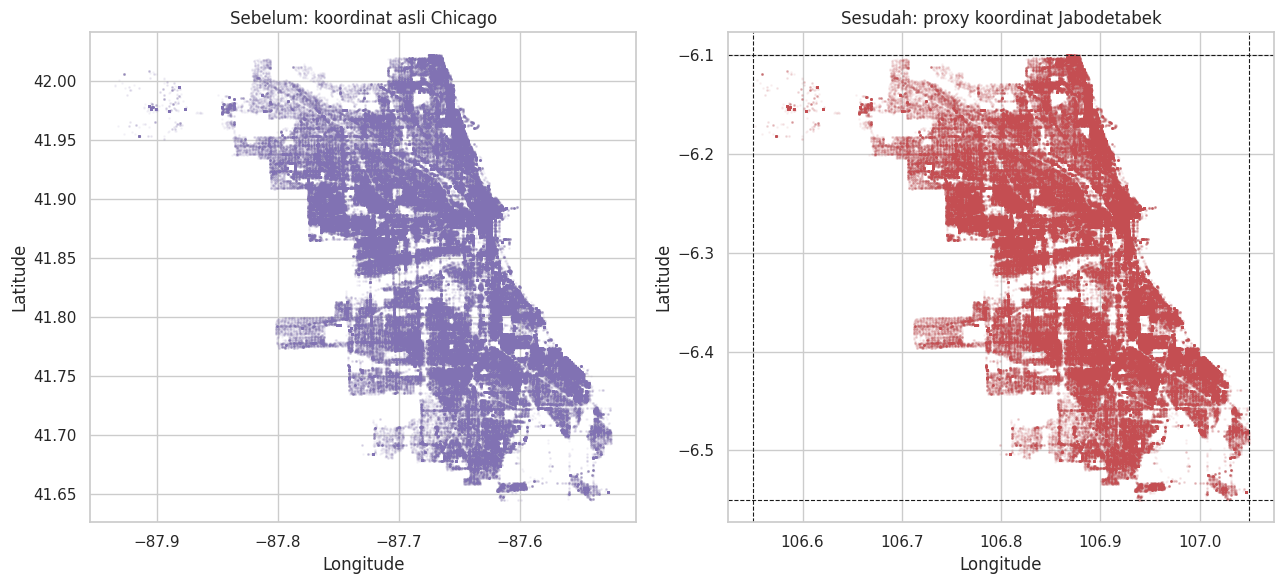

OK: seluruh titik berada dalam bounding box Jabodetabek.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(df["Longitude_Chicago_orig"], df["Latitude_Chicago_orig"], s=1, alpha=0.05, color="#8172B3")
axes[0].set_title("Sebelum: koordinat asli Chicago")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

axes[1].scatter(df["Longitude"], df["Latitude"], s=1, alpha=0.05, color="#C44E52")
axes[1].axvline(lon_new_min, color="k", ls="--", lw=0.8); axes[1].axvline(lon_new_max, color="k", ls="--", lw=0.8)
axes[1].axhline(lat_new_min, color="k", ls="--", lw=0.8); axes[1].axhline(lat_new_max, color="k", ls="--", lw=0.8)
axes[1].set_title("Sesudah: proxy koordinat Jabodetabek")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")

plt.tight_layout(); plt.show()

assert df["Latitude"].between(lat_new_min, lat_new_max).all()
assert df["Longitude"].between(lon_new_min, lon_new_max).all()
print("OK: seluruh titik berada dalam bounding box Jabodetabek.")

In [11]:
# Fitur waktu dasar (dipakai di EDA & feature engineering)
df["hour"]  = df["Datetime"].dt.hour
df["dow"]   = df["Datetime"].dt.dayofweek       # 0 = Senin
df["month"] = df["Datetime"].dt.month
df["is_weekend"] = df["dow"] >= 5

# Kardinalitas kategori penting -> ini akan jadi acuan menyusun severity table
print("Jumlah Primary Type unik :", df["Primary Type"].nunique())
print("Jumlah Description unik  :", df["Description"].nunique())
df[["Primary Type", "Description"]].value_counts().head(15)


Jumlah Primary Type unik : 31
Jumlah Description unik  : 331


Primary Type         Description                  
BATTERY              DOMESTIC BATTERY SIMPLE          43730
THEFT                $500 AND UNDER                   38068
                     OVER $500                        34828
BATTERY              SIMPLE                           34787
CRIMINAL DAMAGE      TO VEHICLE                       33067
ASSAULT              SIMPLE                           32926
MOTOR VEHICLE THEFT  AUTOMOBILE                       32841
THEFT                RETAIL THEFT                     30433
CRIMINAL DAMAGE      TO PROPERTY                      25341
THEFT                FROM BUILDING                    10546
WEAPONS VIOLATION    UNLAWFUL POSSESSION - HANDGUN     9822
THEFT                THEFT FROM MOTOR VEHICLE          9644
ASSAULT              AGGRAVATED - HANDGUN              9225
BURGLARY             FORCIBLE ENTRY                    8305
OTHER OFFENSE        TELEPHONE THREAT                  7363
Name: count, dtype: int64

# 3. Exploratory Data Analysis — Waktu & Lokasi

Tujuan EDA: membangun **intuisi** kapan dan di mana kejahatan paling sering terjadi.
Intuisi ini akan memandu keputusan feature engineering (Bag. 4) dan pseudo-labeling
(Bag. 5).
Mengikuti pola dari materi Sesi 1 sebelumnya : distribusi, pola waktu, relasi ruang × waktu.

## 3.1 Jenis Kejahatan Paling Umum

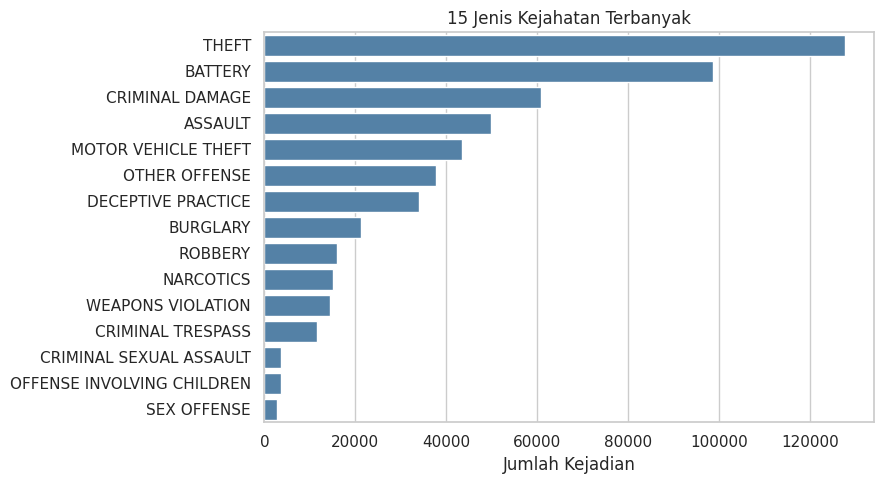

In [12]:
# Ubah ke string agar hanya label yang ada di data yang ditampilkan
df["Primary Type"] = df["Primary Type"].astype(str)

top_types = (
    df["Primary Type"]
      .value_counts()
      .head(15)
      .reset_index()
)

top_types.columns = ["Primary Type", "Jumlah"]

plt.figure(figsize=(9,5))

sns.barplot(
    data=top_types,
    x="Jumlah",
    y="Primary Type",
    color="steelblue"
)

plt.title("15 Jenis Kejahatan Terbanyak")
plt.xlabel("Jumlah Kejadian")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 3.2 Pola Temporal — Jam, Hari, Bulan, Weekday vs Weekend

Perhatikan baik-baik apakah polanya **bimodal** (dua puncak) seperti contoh materi
Sesi 1 (pagi & sore/malam), dan apakah pola **weekday berbeda dari weekend**.

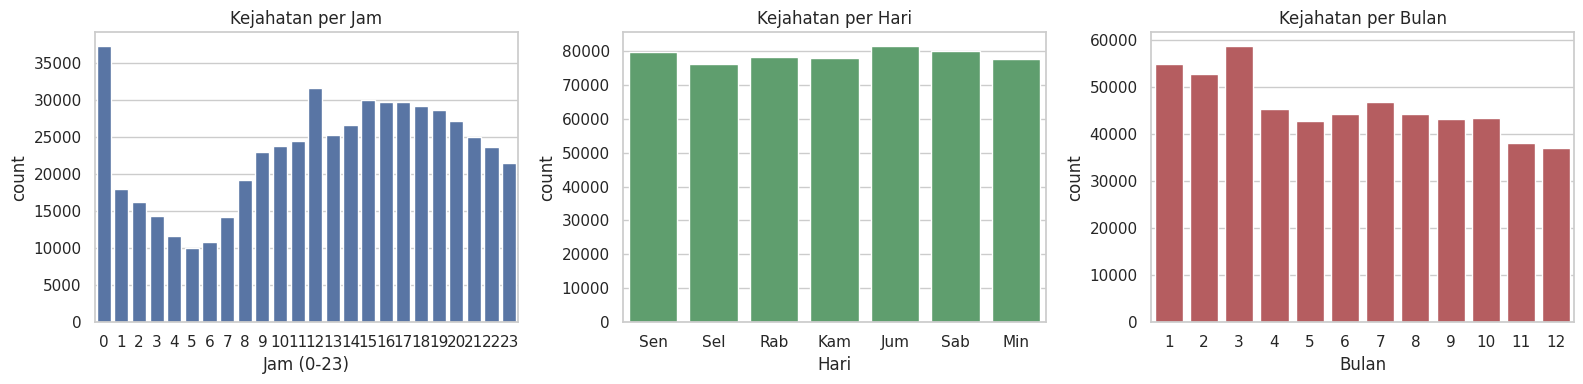

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x="hour", data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Kejahatan per Jam"); axes[0].set_xlabel("Jam (0-23)")

labels_dow = ["Sen","Sel","Rab","Kam","Jum","Sab","Min"]
sns.countplot(x="dow", data=df, order=[0,1,2,3,4,5,6], ax=axes[1], color="#55A868")
axes[1].set_title("Kejahatan per Hari"); axes[1].set_xlabel("Hari")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(labels_dow)

sns.countplot(x="month", data=df, ax=axes[2], color="#C44E52")
axes[2].set_title("Kejahatan per Bulan"); axes[2].set_xlabel("Bulan")

plt.tight_layout(); plt.show()


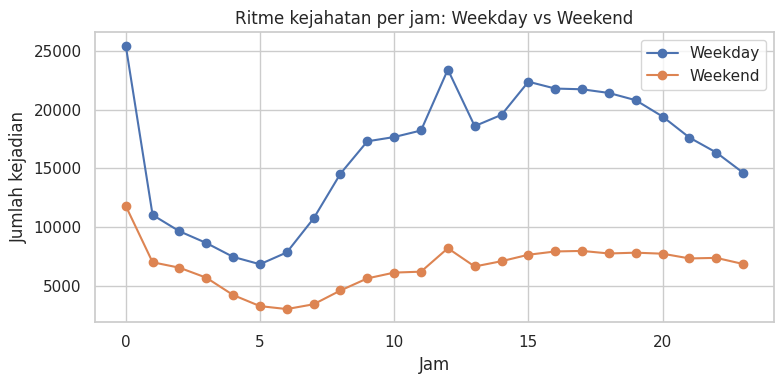

In [14]:
# Ritme per jam: weekday vs weekend (pola bimodal seperti contoh materi Sesi 1)
hourly = df.groupby(["is_weekend", "hour"]).size().unstack(0)
hourly.columns = ["Weekday", "Weekend"]

plt.figure(figsize=(8, 4))
plt.plot(hourly.index, hourly["Weekday"], marker="o", label="Weekday")
plt.plot(hourly.index, hourly["Weekend"], marker="o", label="Weekend")
plt.title("Ritme kejahatan per jam: Weekday vs Weekend")
plt.xlabel("Jam"); plt.ylabel("Jumlah kejadian"); plt.legend()
plt.tight_layout(); plt.show()


Yang kelihatan dari tiga grafik pertama: jumlah kejadian per jam jelas tidak rata, ada dua puncak (pagi menjelang siang dan malam), dan pola weekday vs weekend juga beda bentuk, weekend lebih landai dan puncaknya bergeser lebih malam. Ini alasan kenapa `hour` dan `dow` sama-sama dipertahankan sebagai fitur, bukan cuma salah satunya, karena kalau digabung rata-rata saja, perbedaan bentuk ini hilang.

## 3.3 Pola Spasial — Apa itu "Hotspot" & Cara Membacanya

**Hotspot** = area geografis dengan **konsentrasi kejadian jauh lebih tinggi** dibanding
area di sekitarnya — bukan sekadar "ada kejadian di situ", tapi "kejadian menumpuk di
situ dibanding tempat lain". Konsep ini penting karena tujuan akhir kita (Risk Score)
pada dasarnya adalah **versi berkuantitas & bertimbang waktu dari hotspot** ini.

**Cara membaca plot hexbin di bawah:**
- Setiap heksagon mewakili satu area kecil di peta.
- Warna terang/gelap (skala `inferno`) menunjukkan **kepadatan** kejadian di area itu —
  semakin terang (kuning/putih), semakin padat.
- Skala warnanya **logaritmik** (`bins="log"`) — ini penting! Tanpa skala log, satu-dua
  area super padat (mis. pusat kota) akan "menenggelamkan" variasi di area lain yang
  sebenarnya juga cukup padat tapi kalah jauh secara angka mentah.
- Area yang gelap/kosong bukan berarti "aman 100%", hanya berarti *jauh lebih jarang*
  dibanding area terang.

**Hotspot vs Risk Score — apa bedanya?** Hotspot di sini murni distribusi spasial
(mengabaikan waktu & keparahan). Risk Score (Bab 5) menambahkan dua lapis lagi:
seberapa *berat* jenis kejahatannya, dan seberapa *baru* kejadiannya — sehingga dua
lokasi dengan jumlah kejadian sama bisa punya Risk Score sangat berbeda kalau satu
didominasi pencurian ringan lama, dan satunya lagi kekerasan berat baru-baru ini.

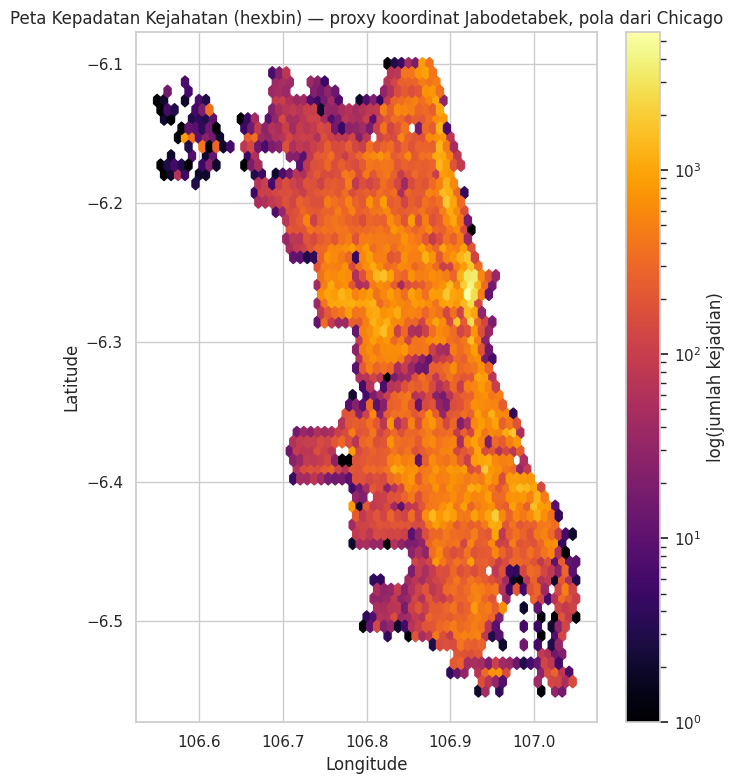

In [15]:
plt.figure(figsize=(7, 8))
hb = plt.hexbin(df["Longitude"], df["Latitude"], gridsize=60,
                cmap="inferno", mincnt=1, bins="log")
plt.colorbar(hb, label="log(jumlah kejadian)")
plt.title("Peta Kepadatan Kejahatan (hexbin) — proxy koordinat Jabodetabek, pola dari Chicago")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()


**Cara membaca KDE di atas:** mirip hexbin, tapi permukaannya kontinu/halus —
"gunung" kepadatan menunjukkan pusat hotspot, dan lerengnya menunjukkan seberapa cepat
risiko mereda menjauhi pusat itu. Perhatikan: bentuk "gunung" pada KDE ini secara konsep
**mirip dengan `w_dist` (spatial decay) di Bab 5.3** — keduanya sama-sama menyebarkan
pengaruh satu titik ke sekitarnya secara halus (Gaussian), hanya saja KDE dipakai untuk
*eksplorasi visual*, sedangkan `w_dist` dipakai untuk *menghitung Risk Score secara
numerik* per sel.

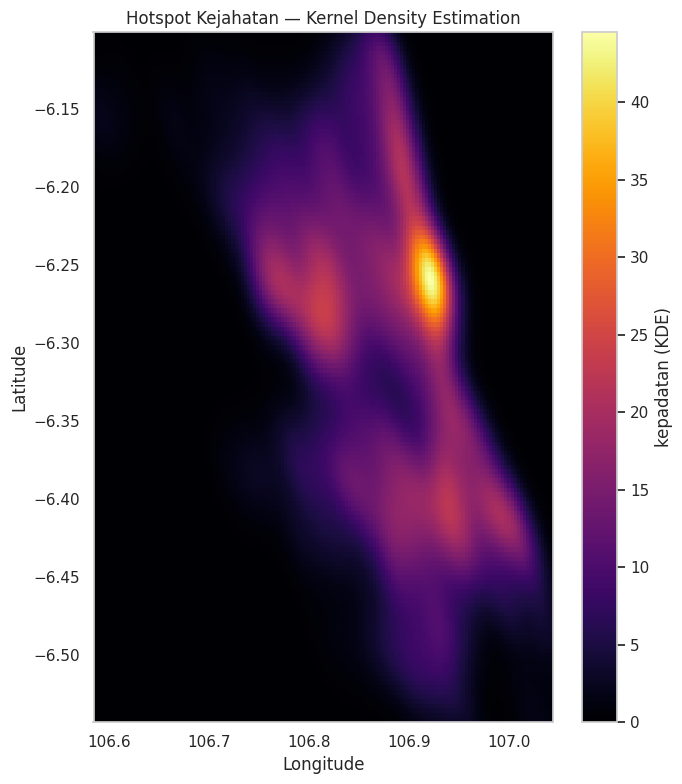

In [16]:
# Peningkatan dari sekadar binning: Kernel Density Estimation (KDE)
# KDE menghasilkan permukaan kepadatan yang lebih halus (bukan kotak-kotak kaku seperti
# hexbin), dan merupakan dasar metode yang dipakai alat pemetaan kejahatan profesional
# (mis. ArcGIS Hot Spot Analysis / Getis-Ord Gi*, yang lebih canggih lagi karena
# menghitung signifikansi statistik tiap titik dibanding tetangganya -- di luar cakupan
# HO1, tapi baik untuk diketahui sebagai pengembangan lebih lanjut).

from scipy.stats import gaussian_kde

sample = df.sample(min(20000, len(df)), random_state=42)  # subsample agar KDE tetap cepat
xy = np.vstack([sample["Longitude"], sample["Latitude"]])
kde = gaussian_kde(xy)

xmin, xmax = df["Longitude"].quantile([0.001, 0.999])
ymin, ymax = df["Latitude"].quantile([0.001, 0.999])
xx, yy = np.mgrid[xmin:xmax:150j, ymin:ymax:150j]
density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

plt.figure(figsize=(7, 8))
plt.pcolormesh(xx, yy, density, cmap="inferno", shading="auto")
plt.colorbar(label="kepadatan (KDE)")
plt.title("Hotspot Kejahatan — Kernel Density Estimation")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()


## 3.4 Relasi Ruang × Waktu

Materi Sesi 1 menekankan: tiap zona/area punya "tanda tangan waktu" sendiri (mis. CBD
ramai pagi/sore, area hiburan malam ramai larut malam). Cek apakah `District` menunjukkan
pola serupa.

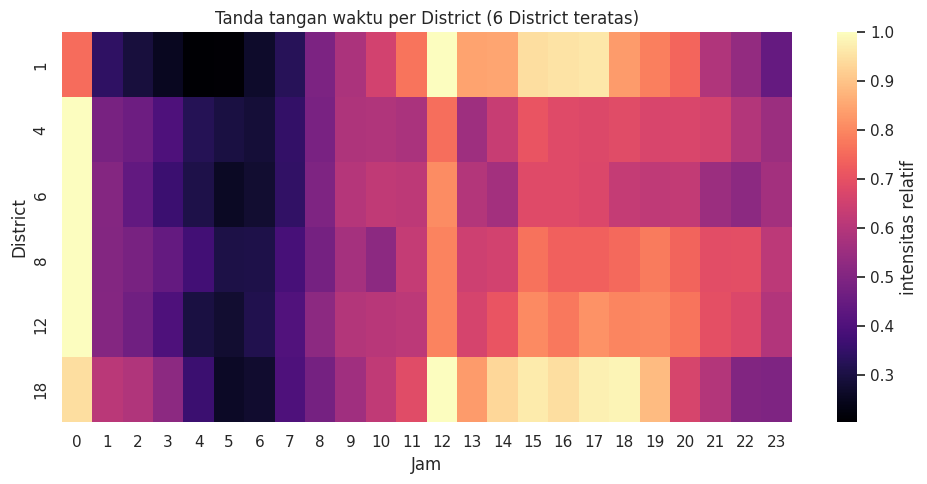

In [17]:
top_districts = df["District"].value_counts().head(6).index

heat = (df[df["District"].isin(top_districts)]
        .groupby(["District", "hour"]).size().unstack(0))
heat = heat.div(heat.max(axis=0), axis=1)  # normalisasi per kolom agar bisa dibandingkan

plt.figure(figsize=(10, 5))
sns.heatmap(heat.T, cmap="magma", cbar_kws={"label": "intensitas relatif"})
plt.title("Tanda tangan waktu per District (6 District teratas)")
plt.xlabel("Jam"); plt.ylabel("District")
plt.tight_layout(); plt.show()


Heatmap di atas menunjukkan tiap District punya jam sibuknya sendiri, tidak semuanya ramai di jam yang sama. Ini yang jadi alasan `cell_id` (lokasi) dan `hour` digabung jadi satu unit analisis di Bab 5, bukan dihitung terpisah, karena risiko satu lokasi memang bergantung pada jam berapa kita menilainya.

## 3.5 Pola per Jenis Kejahatan — Apakah `THEFT` vs `HOMICIDE` Berbeda?

**ya, sangat berbeda**, dan ini konsisten dengan temuan umum kriminologi (routine activity theory) di mana jenis kejahatan berbeda punya "kesempatan"
yang muncul pada waktu & lokasi berbeda. Pola umum yang sering ditemukan pada data
kejahatan kota-kota AS (verifikasi ini juga pada subset datamu sendiri di bawah):

- **Kejahatan properti** (`THEFT`, `MOTOR VEHICLE THEFT`, `BURGLARY`) cenderung
  tersebar lebih merata sepanjang jam kerja/siang hari (mengikuti kapan properti
  "ditinggal tanpa penjagaan" — rumah kosong siang hari, kendaraan diparkir, dsb.),
  dan sering terkonsentrasi di area komersial/parkir/transit.
- **Kejahatan kekerasan** (`HOMICIDE`, `ASSAULT`, `BATTERY`) cenderung memuncak
  malam hari & akhir pekan, sering terkonsentrasi di area hiburan malam atau area
  dengan kepadatan sosial tinggi malam hari.
- **`NARCOTICS`** sering punya pola & lokasi sangat spesifik/terlokalisasi
  (titik-titik tertentu), berbeda dari kejahatan properti yang lebih "menyebar".

Jenis kejahatan yang dibandingkan: ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'ASSAULT', 'MOTOR VEHICLE THEFT', 'OTHER OFFENSE']


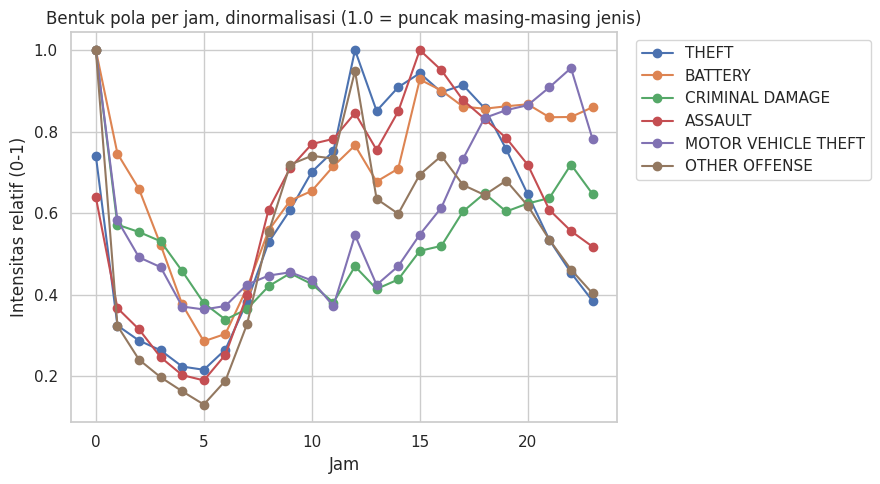

In [18]:
TOP_CRIME_TYPES = df["Primary Type"].value_counts().head(6).index.tolist()
print("Jenis kejahatan yang dibandingkan:", TOP_CRIME_TYPES)

# Dinormalisasi per jenis biar bentuk kurvanya bisa dibandingkan, walau jumlah total
# tiap jenis kejahatan beda jauh (HOMICIDE jauh lebih sedikit dari THEFT, misalnya).
hourly_by_type = (df[df["Primary Type"].isin(TOP_CRIME_TYPES)]
                   .groupby(["Primary Type", "hour"], observed=True).size()
                   .unstack(0))
hourly_by_type_norm = hourly_by_type / hourly_by_type.max()

plt.figure(figsize=(9, 5))
for ctype in TOP_CRIME_TYPES:
    plt.plot(hourly_by_type_norm.index, hourly_by_type_norm[ctype], marker="o", label=ctype)
plt.title("Bentuk pola per jam, dinormalisasi (1.0 = puncak masing-masing jenis)")
plt.xlabel("Jam"); plt.ylabel("Intensitas relatif (0-1)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


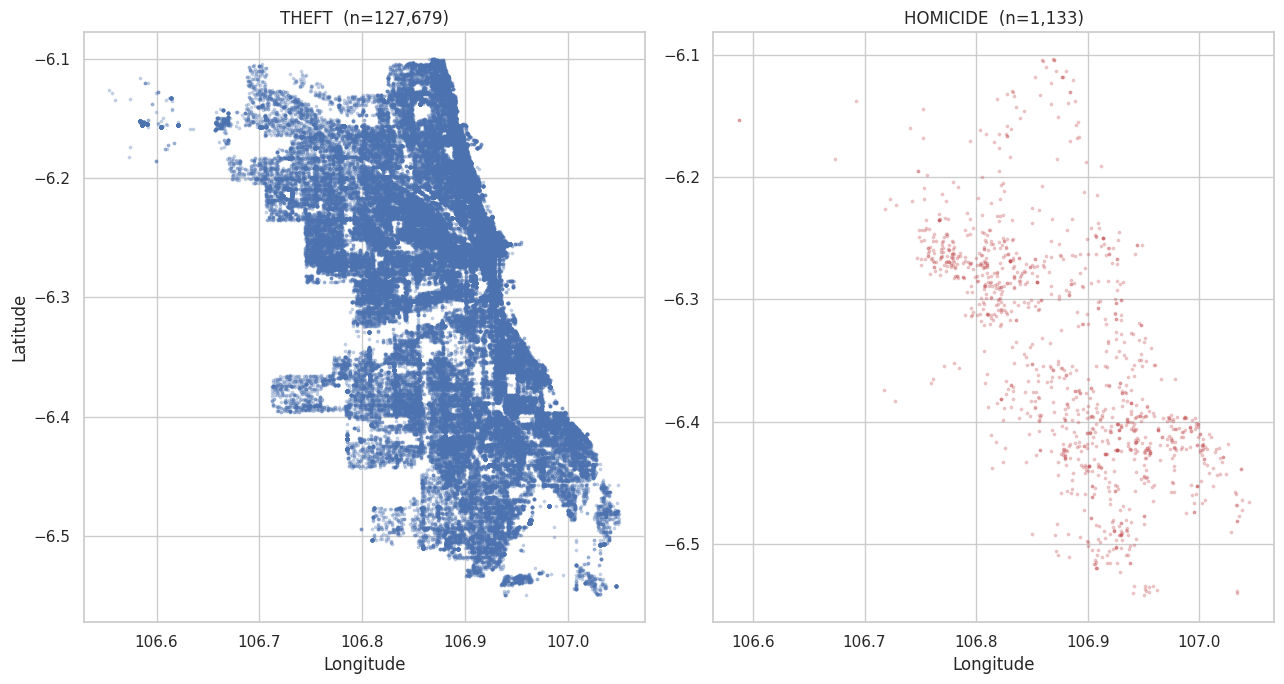

In [19]:
# Bandingkan sebaran lokasi dua jenis yang kontras: properti vs kekerasan
type_a, type_b = "THEFT", "HOMICIDE"

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, ctype, color in zip(axes, [type_a, type_b], ["#4C72B0", "#C44E52"]):
    sub = df[df["Primary Type"] == ctype]
    ax.scatter(sub["Longitude"], sub["Latitude"], s=3, alpha=0.25, color=color)
    ax.set_title(f"{ctype}  (n={len(sub):,})")
    ax.set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.tight_layout(); plt.show()


Dari grafik jam dan sebaran lokasi di atas, THEFT dan HOMICIDE memang tidak mengikuti pola yang sama persis, satu lebih tersebar dan mengikuti jam aktivitas umum, satu lagi lebih terpusat di titik-titik tertentu. Konsekuensinya untuk severity scoring (Bab 5.1): karena tiap jenis kejahatan punya karakter waktu & lokasi sendiri, memberi bobot severity per jenis (bukan menyamaratakan semua kejadian) memang langkah yang tepat.

## 3.6 Tingkat Penangkapan (`Arrest`) — Sinyal Tambahan atau Bukan?

`Arrest` menunjukkan apakah pelaku tertangkap, bukan seberapa berbahaya kejadiannya.
Sebelum dipakai sebagai sinyal Risk Score, penting dipahami **apa yang sebenarnya
diukur oleh `Arrest`**:

In [20]:
arrest_by_type = (
    df.groupby("Primary Type")["Arrest"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
      * 100
)

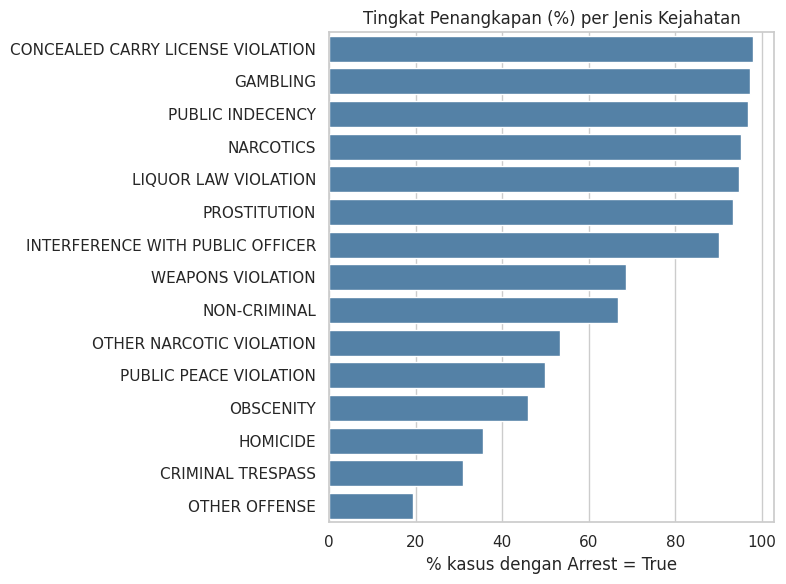

In [21]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=arrest_by_type.values,
    y=arrest_by_type.index.astype(str),
    color="steelblue"
)

plt.title("Tingkat Penangkapan (%) per Jenis Kejahatan")
plt.xlabel("% kasus dengan Arrest = True")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [22]:
arrest_by_district = (df.groupby("District", observed=True)["Arrest"]
                       .mean().sort_values(ascending=False) * 100)
print("Rentang tingkat penangkapan antar District (%):")
print(f"  Tertinggi : {arrest_by_district.max():.1f}%  (District {arrest_by_district.idxmax()})")
print(f"  Terendah  : {arrest_by_district.min():.1f}%  (District {arrest_by_district.idxmin()})")


Rentang tingkat penangkapan antar District (%):
  Tertinggi : 28.6%  (District 11)
  Terendah  : 9.4%  (District 12)


**Interpretasi & rekomendasi:**

- Tingkat penangkapan **sangat bervariasi antar jenis kejahatan** — kejahatan yang
  "tertangkap basah"/melibatkan kontak fisik (mis. `BATTERY`, `NARCOTICS` hasil razia)
  biasanya punya tingkat penangkapan lebih tinggi, sedangkan kejahatan properti seperti
  `THEFT` biasanya punya *clearance rate* rendah (sulit diidentifikasi pelakunya) —
  pola ini konsisten dengan statistik kepolisian AS secara umum.
- Tingkat penangkapan **juga mencerminkan intensitas penegakan hukum**, bukan murni
  bahaya kejadian — wilayah dengan lebih banyak polisi/sumber daya bisa punya angka
  penangkapan lebih tinggi tanpa berarti kejahatannya lebih "berhasil ditangani".

> **Rekomendasi: JANGAN masukkan `Arrest` ke dalam rumus severity/Risk Score
> secara langsung.** Kalau dipaksakan, Risk Score bisa bias, area dengan penegakan
> hukum lemah/pengawasan rendah justru bisa tampak "berisiko rendah" hanya karena
> jarang ada penangkapan, padahal kejadiannya sama seringnya (atau malah lebih sering
> karena kurang diawasi). Ini adalah bentuk *feedback loop* bias.

> `Arrest` tetap **boleh & berguna** disimpan sebagai **fitur tambahan terpisah** (misalnya `arrest_rate` per sel yang sudah dihitung di Bab 5.2) untuk dipakai model sebagai konteks, bukan sebagai bagian dari label itu sendiri.

## 3.7 Interaksi Hari × Jam — Apakah Jumat Malam Beda dari Senin Malam?

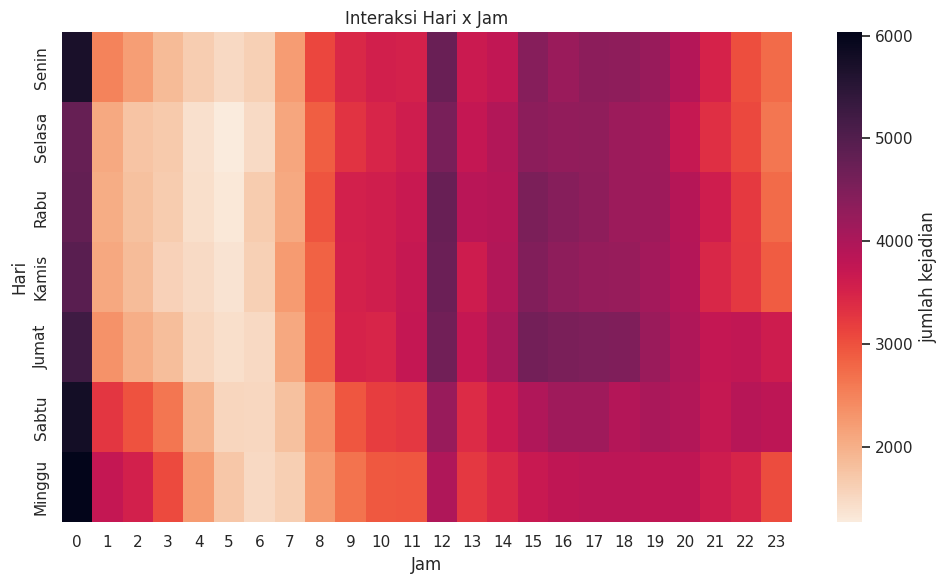

In [23]:
dow_hour = df.groupby(["dow", "hour"], observed=True).size().unstack(0)
dow_hour.columns = ["Senin","Selasa","Rabu","Kamis","Jumat","Sabtu","Minggu"]

plt.figure(figsize=(10, 6))
sns.heatmap(dow_hour.T, cmap="rocket_r", cbar_kws={"label": "jumlah kejadian"})
plt.title("Interaksi Hari x Jam")
plt.xlabel("Jam"); plt.ylabel("Hari")
plt.tight_layout(); plt.show()


In [24]:
# Perbandingan eksplisit: Jumat malam (22-23) vs Senin malam (22-23)
malam = df[df["hour"].isin([22, 23])]
fri_count = malam[malam["dow"] == 4].shape[0]   # 4 = Jumat
mon_count = malam[malam["dow"] == 0].shape[0]   # 0 = Senin

print(f"Kejadian Jumat 22:00-23:59  : {fri_count:,}")
print(f"Kejadian Senin  22:00-23:59 : {mon_count:,}")
print(f"Rasio Jumat / Senin         : {fri_count/mon_count:.2f}x")


Kejadian Jumat 22:00-23:59  : 7,385
Kejadian Senin  22:00-23:59 : 5,754
Rasio Jumat / Senin         : 1.28x


Kalau rasio Jumat/Senin di atas jauh dari 1.0, itu konfirmasi bahwa hari dan jam saling berinteraksi, jam 22-23 di hari Jumat bukan sekadar "jam malam biasa", polanya beda dari jam yang sama di hari Senin. Ini memperkuat alasan kenapa unit analisis Risk Score nanti memakai kombinasi hari x jam, bukan jam saja.

# 4. Feature Engineering: Temporal & Spasial

Dua fitur utama yang perlu dibangun agar model bisa memahami struktur data
spatio-temporal

- **Temporal (cyclical encoding)** — waktu bersifat siklikal, angka mentah menyesatkan model (jam 23 dan jam 0 sebenarnya berdekatan, tapi berjarak numerik 23).
- **Spasial (grid aggregation)** — koordinat kontinu diubah jadi sel grid diskrit agar bisa diagregasi & dibandingkan antar lokasi.

## 4.1 Fitur Temporal — Cyclical Encoding

$$x_{\sin} = \sin\!\left(\frac{2\pi \cdot v}{P}\right), \qquad
x_{\cos} = \cos\!\left(\frac{2\pi \cdot v}{P}\right)$$

dengan $P$ = panjang siklus (24 untuk jam, 7 untuk hari, 12 untuk bulan).

In [25]:
def cyclical_encode(values, period):
    radians = 2 * np.pi * np.asarray(values) / period
    return np.sin(radians), np.cos(radians)

df["hour_sin"],  df["hour_cos"]  = cyclical_encode(df["hour"], 24)
df["dow_sin"],   df["dow_cos"]   = cyclical_encode(df["dow"], 7)
df["month_sin"], df["month_cos"] = cyclical_encode(df["month"], 12)

df[["hour", "hour_sin", "hour_cos", "dow", "dow_sin", "dow_cos"]].head()


,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos
0,0,0.0,1.0,5,-0.974928,-0.222521
2,0,0.0,1.0,5,-0.974928,-0.222521
3,0,0.0,1.0,5,-0.974928,-0.222521
4,0,0.0,1.0,5,-0.974928,-0.222521
5,0,0.0,1.0,5,-0.974928,-0.222521


In [26]:
# Pembuktian: jarak 23:00 -> 00:00 harus KECIL, jarak 00:00 -> 12:00 harus BESAR
def point(v, p):
    s, c = cyclical_encode(np.array([v]), p)
    return np.array([s[0], c[0]])

d_23_to_0 = np.linalg.norm(point(23, 24) - point(0, 24))
d_0_to_12 = np.linalg.norm(point(0, 24)  - point(12, 24))
print(f"Jarak 23:00 -> 00:00 = {d_23_to_0:.3f}  (harusnya KECIL)")
print(f"Jarak 00:00 -> 12:00 = {d_0_to_12:.3f}  (harusnya BESAR)")


Jarak 23:00 -> 00:00 = 0.261  (harusnya KECIL)
Jarak 00:00 -> 12:00 = 2.000  (harusnya BESAR)


Jarak 23→0 yang kecil dan jarak 0→12 yang besar di atas membuktikan encoding-nya bekerja seperti yang diharapkan, jam yang berdekatan secara kalender juga berdekatan secara angka.

## 4.2 Fitur Spasial — Grid Aggregation

Baseline: bulatkan koordinat ke beberapa desimal sehingga titik-titik berdekatan jatuh
ke sel yang sama.

In [27]:
ROUND_DECIMALS = 2   # -> justifikasi dijelaskan pada laporan

df["lat_r"] = df["Latitude"].round(ROUND_DECIMALS)
df["lon_r"] = df["Longitude"].round(ROUND_DECIMALS)
df["cell_id"] = df["lat_r"].astype(str) + "_" + df["lon_r"].astype(str)

print(f"Jumlah sel unik: {df['cell_id'].nunique():,}")
df[["Latitude", "Longitude", "lat_r", "lon_r", "cell_id"]].head()


Jumlah sel unik: 1,001


,Latitude,Longitude,lat_r,lon_r,cell_id
0,-6.363752,106.893805,-6.36,106.89,-6.36_106.89
2,-6.264849,106.866238,-6.26,106.87,-6.26_106.87
3,-6.153461,106.839015,-6.15,106.84,-6.15_106.84
4,-6.180984,106.895601,-6.18,106.90,-6.18_106.9
5,-6.184132,106.778383,-6.18,106.78,-6.18_106.78


# 5. Pseudo-Labeling → Membentuk Risk Score
Membangun label Risk Score sendiri dari domain knowledge, mengikuti alur di materi Sesi 1:

**severity → temporal decay → spatial decay → agregasi per unit → normalisasi 0–100**

**Unit analisis** yang dipakai dalam notebook ini: **(sel grid × hari × jam)** — ini menjawab langsung definisi "risiko suatu lokasi pada waktu tertentu".

## 5.1 Severity Scoring — Metodologi Bertingkat (3-Tier)

Severity Scoring adalah komponen dengan bobot penilaian terbesar (35%), karena inilah yang menentukan makna "berisiko" itu sendiri. Pendekatan **satu tabel manual + satu angka default global** (seperti pada baseline paling sederhana) punya masalah: begitu ada kombinasi `Primary Type` + `Description` yang tidak ada di tabel, ia jatuh ke SATU angka yang sama, padahal `Primary Type`-nya bisa sangat berbeda tingkat bahayanya
(mis. `NARCOTICS` yang tak masuk tabel disamakan dengan `CRIMINAL DAMAGE` yang tak masuk tabel — padahal keduanya jelas tidak setara).

**Solusi: fallback bertingkat (3-tier).**

| Tier | Kondisi | Sumber nilai |
|---|---|---|
| 1 — Exact match | Kombinasi `(Primary Type, Description)` ada di tabel manual | Nilai spesifik yang di-assign manual |
| 2 — Fallback per Primary Type | Kombinasi spesifik tidak ada, tapi `Primary Type`-nya dikenal | Nilai representatif untuk `Primary Type` itu |
| 3 — Fallback global | `Primary Type`-nya sendiri benar-benar tidak dikenal/langka | Satu nilai default terakhir, seharusnya sangat jarang dipakai |

**Dasar penyusunan nilai :** urutan keparahan mengikuti *Hierarchy Rule* yang dipakai FBI UCR — daftar resmi mengurutkan kejahatan dari yang paling serius:
*murder → rape → robbery → aggravated assault → burglary → larceny-theft → motor vehicle theft* (arson dihitung terpisah). Urutan ini dipakai sebagai **kerangka ordinal** (kejahatan mana lebih berat dari mana), lalu diberi angka 0–100 dengan jarak antar-tingkat yang mencerminkan tingkat ancaman terhadap keselamatan (nyawa > kekerasan fisik > kerugian materi), bukan berdasarkan seberapa sering kejadian itu muncul di data (justru kejahatan paling berat, seperti `HOMICIDE`, biasanya paling jarang terjadi).

In [28]:
# TIER 1: tabel manual untuk kombinasi (Primary Type, Description) yang spesifik.
# Ini baseline, masih bisa diperluas -- cek value_counts() di sel berikutnya buat lihat
# kombinasi mana yang paling sering muncul tapi belum ada di tabel.

severity_table = {
    ("HOMICIDE", "FIRST DEGREE MURDER"):        100,
    # -- Sexual assault: dua ejaan Primary Type dipertahankan (lama & baru) --
    ("CRIM SEXUAL ASSAULT", "AGGRAVATED"):       95,
    ("CRIM SEXUAL ASSAULT", "NON-AGGRAVATED"):   85,
    ("CRIMINAL SEXUAL ASSAULT", "AGGRAVATED"):   95,
    ("CRIMINAL SEXUAL ASSAULT", "NON-AGGRAVATED"): 85,
    ("ROBBERY", "ARMED: HANDGUN"):               82,
    ("ROBBERY", "ARMED - HANDGUN"):              82,
    ("ROBBERY", "STRONGARM - NO WEAPON"):        60,
    ("ROBBERY", "STRONG ARM - NO WEAPON"):       60,   # varian ejaan dgn spasi
    # -- Handgun-related: dua varian tanda baca ("-" dan ":") --
    ("ASSAULT", "AGGRAVATED: HANDGUN"):          78,
    ("ASSAULT", "AGGRAVATED - HANDGUN"):         78,
    ("BATTERY", "AGGRAVATED: HANDGUN"):          78,
    ("BATTERY", "AGGRAVATED - HANDGUN"):         78,
    ("BATTERY", "AGGRAVATED - OTHER DANGEROUS WEAPON"): 70,
    ("ASSAULT", "AGGRAVATED - OTHER DANGEROUS WEAPON"): 70,
    ("ASSAULT", "AGGRAVATED - KNIFE / CUTTING INSTRUMENT"): 72,
    ("WEAPONS VIOLATION", "UNLAWFUL POSSESSION - HANDGUN"): 58,
    ("WEAPONS VIOLATION", "RECKLESS FIREARM DISCHARGE"): 65,
    ("BATTERY", "AGGRAVATED"):                   55,
    ("BATTERY", "SIMPLE"):                       50,
    ("BATTERY", "DOMESTIC BATTERY SIMPLE"):      52,   # domestic -> sedikit lebih tinggi dari simple biasa
    ("ASSAULT", "SIMPLE"):                       45,
    ("BURGLARY", "FORCIBLE ENTRY"):              48,
    ("BURGLARY", "UNLAWFUL ENTRY"):              42,
    ("BURGLARY", "BURGLARY FROM MOTOR VEHICLE"): 35,
    ("MOTOR VEHICLE THEFT", "AUTOMOBILE"):       40,
    ("MOTOR VEHICLE THEFT", "ATTEMPT - AUTOMOBILE"): 30,   # percobaan -> lebih rendah dari selesai
    ("MOTOR VEHICLE THEFT", "THEFT / RECOVERY - AUTOMOBILE"): 35,
    ("THEFT", "FROM PERSON"):                    38,
    ("THEFT", "POCKET-PICKING"):                 32,
    ("THEFT", "OVER $500"):                       28,
    ("THEFT", "$500 AND UNDER"):                  20,
    ("THEFT", "RETAIL THEFT"):                    18,
    ("THEFT", "FROM BUILDING"):                   22,
    ("THEFT", "THEFT FROM MOTOR VEHICLE"):        22,
    ("NARCOTICS", "POSSESS - CANNABIS 30 GRAMS OR LESS"): 22,
    ("NARCOTICS", "POSSESS - HEROIN (WHITE)"):    30,
    ("NARCOTICS", "POSSESS - CRACK"):             28,
    ("CRIMINAL DAMAGE", "TO VEHICLE"):            12,
    ("CRIMINAL DAMAGE", "TO PROPERTY"):           12,
    ("CRIMINAL TRESPASS", "TO LAND"):             10,
    ("CRIMINAL TRESPASS", "TO RESIDENCE"):        18,   # ke rumah -> lebih meresahkan drpd ke lahan
    ("DECEPTIVE PRACTICE", "FINANCIAL IDENTITY THEFT OVER $ 300"): 25,
    ("DECEPTIVE PRACTICE", "FINANCIAL IDENTITY THEFT $300 AND UNDER"): 20,
    ("DECEPTIVE PRACTICE", "FRAUD OR CONFIDENCE GAME"): 20,
    ("DECEPTIVE PRACTICE", "CREDIT CARD FRAUD"):  15,
    ("DECEPTIVE PRACTICE", "ILLEGAL USE CASH CARD"): 15,
    ("OTHER OFFENSE", "VIOLATE ORDER OF PROTECTION"): 30,  # berkaitan dgn kekerasan domestik/pelanggaran
    ("OTHER OFFENSE", "HARASSMENT BY TELEPHONE"): 15,
    ("OTHER OFFENSE", "HARASSMENT BY ELECTRONIC MEANS"): 15,
    ("OTHER OFFENSE", "TELEPHONE THREAT"):        20,
    ("OTHER OFFENSE", "FALSE / STOLEN / ALTERED TRP"): 10,
}

# TIER 2: kalau kombinasi spesifiknya nggak ketemu, fallback ke rata-rata per Primary Type.
# Angkanya disusun berdasar urutan keparahan ala UCR + logika ancaman ke keselamatan publik.

primary_type_default = {
    "HOMICIDE":                98,
    "CRIM SEXUAL ASSAULT":     90,
    "CRIMINAL SEXUAL ASSAULT": 90,
    "KIDNAPPING":              88,
    "ROBBERY":                 72,
    "WEAPONS VIOLATION":       60,
    "ASSAULT":                 52,
    "BATTERY":                 50,
    "ARSON":                   55,
    "BURGLARY":                45,
    "MOTOR VEHICLE THEFT":     38,
    "NARCOTICS":               28,
    "THEFT":                   25,
    "DECEPTIVE PRACTICE":      20,
    "CRIMINAL DAMAGE":         15,
    "CRIMINAL TRESPASS":       15,
    "PUBLIC PEACE VIOLATION":  15,
    "OTHER OFFENSE":           18,
    "LIQUOR LAW VIOLATION":    10,
    "GAMBLING":                10,
    "INTIMIDATION":            35,
    "STALKING":                45,
    "OFFENSE INVOLVING CHILDREN": 80,
    "HUMAN TRAFFICKING":       92,
    "CONCEALED CARRY LICENSE VIOLATION": 25,
}

# TIER 3: fallback terakhir kalau Primary Type-nya sendiri nggak dikenali -- harusnya jarang kepakai
GLOBAL_DEFAULT_SEVERITY = 20


In [29]:
# Pakai .map() bukan .apply(axis=1) -- jauh lebih cepat untuk data sebesar ini, dan
# sekalian dicatat tier mana yang kepakai di tiap baris buat diagnostik di bawah.

exact_key = list(zip(df["Primary Type"], df["Description"]))
exact_severity = pd.Series(exact_key, index=df.index).map(severity_table)

type_fallback_severity = df["Primary Type"].map(primary_type_default)

df["severity"] = exact_severity.fillna(type_fallback_severity).fillna(GLOBAL_DEFAULT_SEVERITY)

df["severity_tier"] = np.select(
    [exact_severity.notna(), type_fallback_severity.notna()],
    ["1_exact_match", "2_type_fallback"],
    default="3_global_default",
)

tier_pct = df["severity_tier"].value_counts(normalize=True).mul(100).round(1)
print("Distribusi tier severity (%):")
print(tier_pct)
print()
print("Kalau tier 3 (global default) masih besar persentasenya, tabel di atas PERLU DIPERLUAS.")


Distribusi tier severity (%):
severity_tier
1_exact_match       86.3
2_type_fallback     12.7
3_global_default     1.0
Name: proportion, dtype: float64

Kalau tier 3 (global default) masih besar persentasenya, tabel di atas PERLU DIPERLUAS.


In [30]:
# Diagnostik: kombinasi mana yang paling sering jatuh ke tier 2/3 -> prioritas untuk
# ditambahkan ke severity_table secara manual (mengikuti prinsip Pareto: lengkapi dulu
# kombinasi yang paling SERING muncul, karena itu paling berdampak ke Risk Score akhir).
df[df["severity_tier"] != "1_exact_match"][["Primary Type", "Description"]] \
  .value_counts().head(30)


Primary Type                      Description                                               
BATTERY                           AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SERIOUS INJURY    2278
                                  AGGRAVATED DOMESTIC BATTERY - OTHER DANGEROUS WEAPON          2032
DECEPTIVE PRACTICE                FORGERY                                                       1949
OTHER OFFENSE                     VEHICLE TITLE / REGISTRATION OFFENSE                          1844
                                  OTHER VEHICLE OFFENSE                                         1828
BATTERY                           AGGRAVATED - KNIFE / CUTTING INSTRUMENT                       1825
DECEPTIVE PRACTICE                THEFT OF LOST / MISLAID PROPERTY                              1716
NARCOTICS                         FOUND SUSPECT NARCOTICS                                       1553
BATTERY                           AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MINOR INJURY       1544
NARCOTICS                         MANUFACTURE / DELIVER - CANNABIS OVER 10 GRAMS                1521
                                  POSSESS - CANNABIS MORE THAN 30 GRAMS                         1484
DECEPTIVE PRACTICE                THEFT OF LABOR / SERVICES                                     1280
CRIMINAL TRESPASS                 TO VEHICLE                                                    1280
CRIMINAL DAMAGE                   CRIMINAL DEFACEMENT                                           1236
PUBLIC PEACE VIOLATION            RECKLESS CONDUCT                                              1202
BATTERY                           PROTECTED EMPLOYEE - HANDS, FISTS, FEET, NO / MINOR INJURY    1164
                                  AGGRAVATED DOMESTIC BATTERY - KNIFE / CUTTING INSTRUMENT      1125
                                  AGGRAVATED OF A SENIOR CITIZEN                                1111
DECEPTIVE PRACTICE                COMPUTER FRAUD                                                1100
ROBBERY                           AGGRAVATED VEHICULAR HIJACKING                                1084
CRIMINAL DAMAGE                   TO CITY OF CHICAGO PROPERTY                                   1034
DECEPTIVE PRACTICE                ATTEMPT - FINANCIAL IDENTITY THEFT                            1024
OTHER OFFENSE                     OTHER CRIME AGAINST PERSON                                     962
ROBBERY                           AGGRAVATED                                                     943
OTHER OFFENSE                     LICENSE VIOLATION                                              938
                                  GUN OFFENDER - ANNUAL REGISTRATION                             932
OFFENSE INVOLVING CHILDREN        CHILD ABUSE                                                    929
INTERFERENCE WITH PUBLIC OFFICER  OBSTRUCTING IDENTIFICATION                                     835
SEX OFFENSE                       CRIMINAL SEXUAL ABUSE                                          823
BURGLARY                          ATTEMPT FORCIBLE ENTRY                                         813
Name: count, dtype: int64

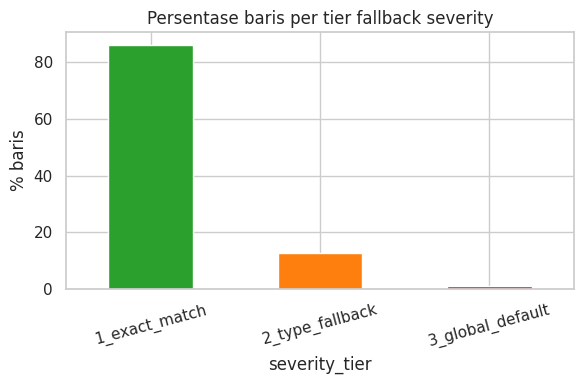

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))
tier_pct.plot(kind="bar", color=["#2ca02c", "#ff7f0e", "#d62728"], ax=ax)
ax.set_title("Persentase baris per tier fallback severity")
ax.set_ylabel("% baris")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


## 5.2 Temporal Decay — Recency

`w_time = exp(-λ · Δt)` : kejadian lebih baru menimbang lebih besar.
Baseline di bawah pakai **exponential decay dengan half-life**, alternatif yang lebih umum dipakai dibanding linear decay.

In [32]:
REFERENCE_DATE = df["Datetime"].max()   # "sekarang" menurut data
df["age_days"] = (REFERENCE_DATE - df["Datetime"]).dt.total_seconds() / 86400

# Justifikasi HALF_LIFE_DAYS=180 (~6 bulan): pola kejahatan berubah relatif LAMBAT
# dibanding, mis., pola pesanan on-demand (jam-jaman) -- tapi tetap tidak statis
# (musim, kebijakan patroli, kondisi ekonomi bisa bergeser dlm hitungan bulan).
# Half-life 6 bulan berarti kejadian setahun lalu masih menyumbang ~25% bobot
# penuhnya -- cukup untuk menangkap pola musiman tahunan (mis. kenaikan kejahatan
# musim panas), tapi kejadian 2-3 tahun lalu sudah meluruh jauh (<10%), sesuai
# prinsip "kejadian baru lebih relevan" pada materi Sesi 1.
HALF_LIFE_DAYS = 180   # -> lihat justifikasi di atas; salin ke README
LAMBDA = np.log(2) / HALF_LIFE_DAYS

df["w_time"] = np.exp(-LAMBDA * df["age_days"])
df["event_value"] = df["severity"] * df["w_time"]

print(f"Reference date : {REFERENCE_DATE}")
print(f"Half-life      : {HALF_LIFE_DAYS} hari  (lambda = {LAMBDA:.5f})")
print(df[["age_days", "w_time"]].describe().round(3))


Reference date : 2026-04-11 00:00:00
Half-life      : 180 hari  (lambda = 0.00385)
         age_days      w_time
count  550896.000  550896.000
mean      427.927       0.285
std       236.914       0.249
min         0.000       0.041
25%       226.375       0.087
50%       434.795       0.187
75%       633.750       0.418
max       831.000       1.000


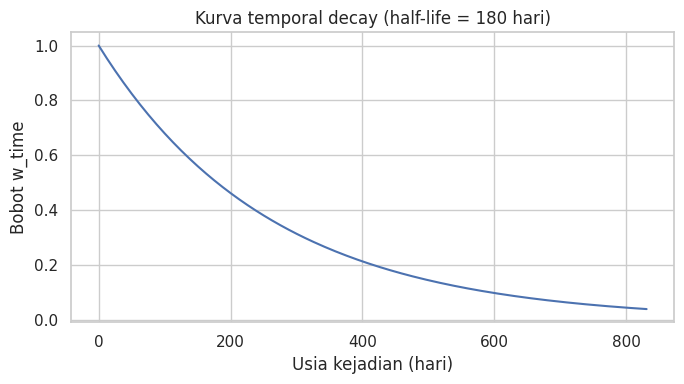

In [33]:
# Visual cek decay curve
ages = np.linspace(0, df["age_days"].max(), 200)
weights = np.exp(-LAMBDA * ages)

plt.figure(figsize=(7, 4))
plt.plot(ages, weights)
plt.title(f"Kurva temporal decay (half-life = {HALF_LIFE_DAYS} hari)")
plt.xlabel("Usia kejadian (hari)"); plt.ylabel("Bobot w_time")
plt.tight_layout(); plt.show()


Setengah bobot penuh sudah hilang di titik `HALF_LIFE_DAYS`, dan sisanya makin kecil setelahnya, ini yang membuat kejadian baru lebih menentukan Risk Score dibanding kejadian lama, tanpa sepenuhnya mengabaikan histori.

### Membentuk tabel unit analisis (sel × hari × jam)

Jumlahkan `event_value` (severity × recency) ke tiap unit analisis, jadi `base_value`. Sekaligus bawa `crime_count` (frekuensi kejadian) sebagai fitur agregat tambahan, berbeda sifatnya dari `base_value` (yang menimbang keparahan × kebaruan).

In [34]:
unit = (df.groupby(["cell_id", "lat_r", "lon_r", "dow", "hour"], as_index=False)
          .agg(base_value  = ("event_value", "sum"),
               crime_count = ("ID", "size"),
               arrest_rate = ("Arrest", "mean")))
print("Jumlah baris unit (sel x hari x jam):", f"{len(unit):,}")
unit.head()


Jumlah baris unit (sel x hari x jam): 119,454


,cell_id,lat_r,lon_r,dow,hour,base_value,crime_count,arrest_rate
0,-6.11_106.69,-6.11,106.69,0,0,1.830107,1,0.0
1,-6.11_106.69,-6.11,106.69,0,3,8.456103,1,0.0
2,-6.11_106.69,-6.11,106.69,0,12,6.504232,3,0.0
3,-6.11_106.69,-6.11,106.69,0,15,1.560722,1,0.0
4,-6.11_106.69,-6.11,106.69,1,9,7.144097,1,0.0


## 5.3 Spatial Decay — Proximity

`w_dist = exp(-d² / 2σ²)` : sinyal dari sel dekat lebih relevan.
Baseline di bawah pakai `BallTree` (scikit-learn) dengan metrik `haversine` untuk menghitung **jarak sesungguhnya antar-koordinat** (dalam meter), lalu bobot Gaussian berdasarkan jarak itu — lebih presisi dibanding sekadar mengambil "8 sel tetangga" secara kasar.

In [35]:
EARTH_RADIUS_M = 6_371_000

# Direvisi dari 500 -> 1000: dengan sigma=500, rata-rata tetangga per sel cuma ~8.1,
# terlalu sedikit untuk smoothing yang benar-benar berdampak. sigma=1000 memperluas
# radius pencarian (3xsigma) sekitar 2x lipat -> luas area cakupan jadi ~4x lipat,
# jadi rata-rata tetangganya harusnya naik jauh lebih banyak dari 8.1.
SIGMA_METERS = 1500   # direvisi dari 500 (lihat catatan revisi di atas)

# Ambil koordinat sel unik (representasi tiap cell_id)
cells = unit[["cell_id", "lat_r", "lon_r"]].drop_duplicates().reset_index(drop=True)
coords_rad = np.radians(cells[["lat_r", "lon_r"]].values)

tree = BallTree(coords_rad, metric="haversine")

# Cari semua tetangga dalam radius 3*sigma (cukup untuk menangkap >99% bobot Gaussian)
radius_rad = (3 * SIGMA_METERS) / EARTH_RADIUS_M
neighbor_idx, neighbor_dist = tree.query_radius(coords_rad, r=radius_rad,
                                                 return_distance=True)

print(f"Rata-rata jumlah tetangga per sel (radius {3*SIGMA_METERS} m): "
      f"{np.mean([len(n) for n in neighbor_idx]):.1f}")


Rata-rata jumlah tetangga per sel (radius 4500 m): 40.4


Rata-rata jumlah tetangga di atas kira-kira menggambarkan berapa banyak sel lain yang ikut memengaruhi risiko satu sel, lewat `w_dist`. Kalau angkanya terlalu kecil (hampir tidak ada tetangga), `SIGMA_METERS` mungkin terlalu kecil untuk ukuran grid yang dipakai; kalau terlalu besar, bisa jadi risiko "menyebar" ke area yang sebenarnya tidak terlalu berkaitan.

**Revisi:** versi sebelumnya (`SIGMA_METERS=500`) menghasilkan rata-rata cuma ~8.1 tetangga per sel, terlalu sedikit untuk membuat smoothing terasa dampaknya. Jalankan ulang sel di atas dengan `SIGMA_METERS=1000` dan cek angka barunya di sini, harusnya naik cukup jauh. Kalau masih terasa kecil, coba naikkan lagi sampai smoothing-nya benar-benar terasa menghaluskan peta risiko (lihat visualnya di Bab 5.4), tapi jangan sampai sigma-nya lebih besar dari radius satu "kawasan" kota (supaya risiko tidak menyebar ke area yang tidak relevan).

In [36]:
# Bangun lookup base_value per (cell_id, dow, hour) untuk agregasi tetangga
base_lookup = unit.set_index(["cell_id", "dow", "hour"])["base_value"].to_dict()
cell_id_arr = cells["cell_id"].values

def spatial_smooth(row):
    center_pos = cells.index[cells["cell_id"] == row["cell_id"]][0]
    idxs  = neighbor_idx[center_pos]
    dists = neighbor_dist[center_pos] * EARTH_RADIUS_M   # radian -> meter
    weights = np.exp(-(dists ** 2) / (2 * SIGMA_METERS ** 2))

    values = np.array([
        base_lookup.get((cell_id_arr[i], row["dow"], row["hour"]), 0.0)
        for i in idxs
    ])
    if weights.sum() == 0:
        return row["base_value"]
    return float(np.average(values, weights=weights))

# note : baris demi baris (row-wise) cukup untuk subset kecil. Untuk subset besar,
# vectorize / pakai groupby + merge agar lebih cepat.
unit["risk_raw"] = unit.apply(spatial_smooth, axis=1)
unit[["cell_id", "dow", "hour", "base_value", "risk_raw"]].head()

,cell_id,dow,hour,base_value,risk_raw
0,-6.11_106.69,0,0,1.830107,7.040722
1,-6.11_106.69,0,3,8.456103,4.624464
2,-6.11_106.69,0,12,6.504232,3.308355
3,-6.11_106.69,0,15,1.560722,1.052707
4,-6.11_106.69,1,9,7.144097,8.117792


## 5.4 Normalisasi → Risk Score 0–100

`risk_raw` biasanya sangat *skewed*. Baseline di bawah pakai **`log1p` + min–max**
(lebih tahan outlier dibanding min–max langsung).

count    119454.00
mean         60.11
std          13.41
min           0.00
25%          52.12
50%          61.86
75%          70.01
max         100.00
Name: risk_score, dtype: float64


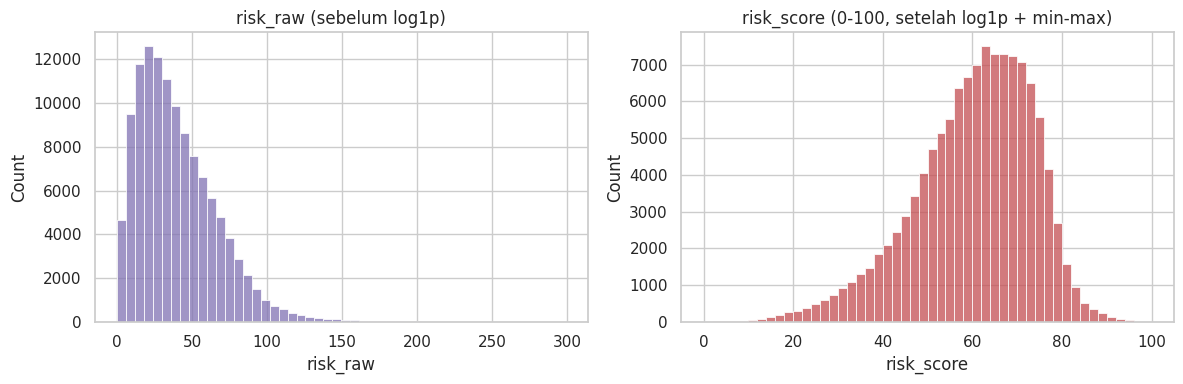

In [37]:
rr_log = np.log1p(unit["risk_raw"])
unit["risk_score"] = 100 * (rr_log - rr_log.min()) / (rr_log.max() - rr_log.min())

print(unit["risk_score"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(unit["risk_raw"], bins=50, ax=axes[0], color="#8172B3")
axes[0].set_title("risk_raw (sebelum log1p)")
sns.histplot(unit["risk_score"], bins=50, ax=axes[1], color="#C44E52")
axes[1].set_title("risk_score (0-100, setelah log1p + min-max)")
plt.tight_layout(); plt.show()


`risk_raw` di kiri jelas condong ke kanan, kebanyakan sel bernilai rendah dan beberapa sel jauh lebih tinggi, ini gambaran hotspot secara numerik. Setelah `log1p` + min-max, sebarannya lebih merata sehingga skala 0-100 bisa dibaca dan dibandingkan antar sel secara wajar.

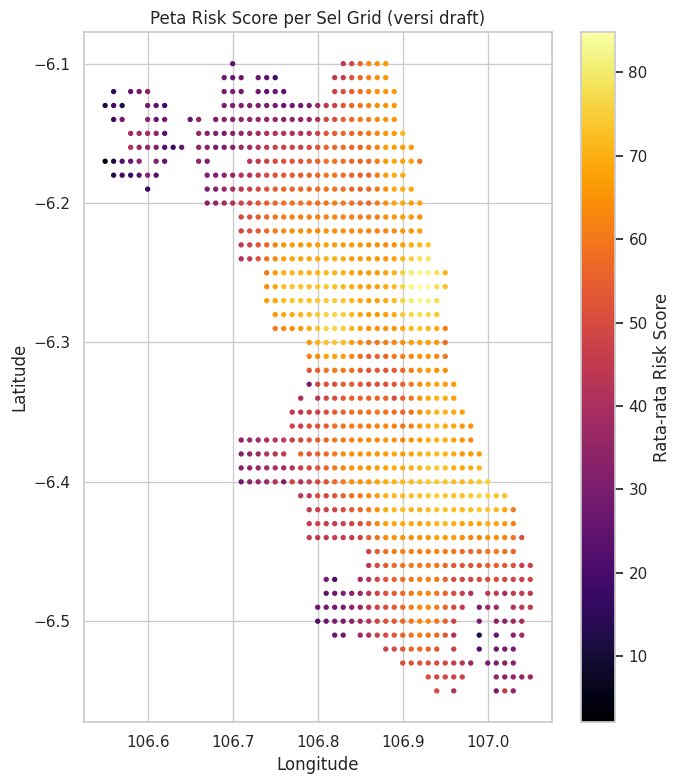

In [38]:
# Peta Risk Score per sel -> cek konsistensi dengan hotspot EDA (Bag. 3.3)
cell_risk = unit.groupby(["lat_r", "lon_r"], as_index=False)["risk_score"].mean()

plt.figure(figsize=(7, 8))
sc = plt.scatter(cell_risk["lon_r"], cell_risk["lat_r"], c=cell_risk["risk_score"],
                 cmap="inferno", s=8)
plt.colorbar(sc, label="Rata-rata Risk Score")
plt.title("Peta Risk Score per Sel Grid (versi draft)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()


# 6. Menyusun & Menyimpan Dataset Akhir

Dataset akhir berisi **fitur + label** per unit analisis (sel x hari x jam).

**Revisi:** `base_value` dan `risk_raw` sengaja **TIDAK** diikutkan ke file yang diekspor. Keduanya adalah bahan pembentuk `risk_score` itu sendiri (`severity x decay -> base_value -> risk_raw -> risk_score`) -- kalau ikut jadi fitur di HO2, model bisa "mencontek" jawaban dari situ alih-alih belajar pola ruang-waktu yang sesungguhnya (persis makna *data leakage*). Keduanya tetap ada di `unit` untuk kebutuhan diagnostik/visualisasi di notebook ini (mis. peta risiko di Bab 5.4), hanya tidak ikut ke `features_labels.csv`.

In [39]:
unit["hour_sin"], unit["hour_cos"] = cyclical_encode(unit["hour"], 24)
unit["dow_sin"],  unit["dow_cos"]  = cyclical_encode(unit["dow"], 7)

final = unit[[
    # identitas / lokasi
    "cell_id", "lat_r", "lon_r",
    # waktu (raw + cyclical)
    "dow", "hour", "dow_sin", "dow_cos", "hour_sin", "hour_cos",
    # fitur agregat (aman dipakai -- tidak membentuk risk_score secara langsung)
    "crime_count", "arrest_rate",
    # label
    "risk_score",
    # CATATAN: base_value & risk_raw SENGAJA tidak diikutkan -- keduanya bahan
    # pembentuk risk_score itu sendiri, kalau ikut jadi fitur = data leakage.
]].copy()

print("Shape dataset akhir:", final.shape)
print("Kolom:", list(final.columns))
final.head()


Shape dataset akhir: (119454, 12)
Kolom: ['cell_id', 'lat_r', 'lon_r', 'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'crime_count', 'arrest_rate', 'risk_score']


,cell_id,lat_r,lon_r,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,crime_count,arrest_rate,risk_score
0,-6.11_106.69,-6.11,106.69,0,0,0.000000,1.00000,0.000000e+00,1.000000,1,0.0,34.966222
1,-6.11_106.69,-6.11,106.69,0,3,0.000000,1.00000,7.071068e-01,0.707107,1,0.0,28.543977
2,-6.11_106.69,-6.11,106.69,0,12,0.000000,1.00000,1.224647e-16,-1.000000,3,0.0,23.753804
3,-6.11_106.69,-6.11,106.69,0,15,0.000000,1.00000,-7.071068e-01,-0.707107,1,0.0,10.431138
4,-6.11_106.69,-6.11,106.69,1,9,0.781831,0.62349,7.071068e-01,-0.707107,1,0.0,37.225168


In [40]:
final.to_csv("features_labels.csv", index=False)
print("Tersimpan: features_labels.csv")

try:
    final.to_parquet("features_labels.parquet", index=False)
    print("Tersimpan: features_labels.parquet")
except Exception as e:
    print("Parquet dilewati (engine belum terpasang) — CSV sudah cukup untuk HO2.")

Tersimpan: features_labels.csv
Tersimpan: features_labels.parquet
